# Preprocesado y Feature Engineering

En este notebook transformamos el dataset saneado (`data_sanitized.csv`) de transacciones individuales en una **serie temporal diaria** lista para ser modelizada, enriqueciéndola mediante ingeniería de variables.

El notebook es **autosuficiente**: carga el CSV desde disco sin depender de ningún notebook previo.

Las etapas que se realizan son:
- **4.1** Agregación diaria y creación de la variable objetivo `Ventas`
- **4.2** Variables categóricas de resumen diario (producto top, país top, clientes únicos)
- **4.3** Extracción de variables temporales desde la fecha
- **4.4** Análisis y limpieza de las nuevas variables
- **4.6** Análisis de correlación y selección de variables
- **4.7** Lags (retrasos temporales)
- **4.8** Medias móviles
- **4.9** Eventos especiales
- **4.10** Escalado y exportación (train/test split + CSV)


## 0. Imports y Carga del Dataset

Preparamos el entorno de trabajo: importamos librerías, configuramos la estética visual y definimos las rutas del proyecto.

A continuación cargamos `data_sanitized.csv` — el CSV limpio exportado por el notebook de limpieza — que ya incluye las columnas auxiliares `Fecha`, `Mes`, `DiaSemana`, `EsCancelacion` y `TotalPrice`, por lo que no es necesario recalcularlas.

Se inicializa también el diccionario de auditoría `stats_preprocesing` que registrará las transformaciones realizadas en este notebook.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

# Rutas del proyecto
RUTA_INTERIM   = '../../../data/interim/'
RUTA_GRAFICOS  = '../../../graphics/'
RUTA_PROCESSED = '../../../data/processed/'
os.makedirs(RUTA_GRAFICOS,  exist_ok=True)
os.makedirs(RUTA_PROCESSED, exist_ok=True)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [4]:
# Carga del CSV limpio (output del notebook de limpieza)
df_raw     = pd.read_csv(
    RUTA_INTERIM + 'data_sanitized.csv',
    parse_dates=['InvoiceDate', 'Fecha']
)
df_working = df_raw.copy()

# EsCancelacion puede llegar como string 'True'/'False' → forzar a bool
df_working['EsCancelacion'] = df_working['EsCancelacion'].astype(bool)

# Diccionario de auditoría (se actualiza en cada paso de transformación)
stats_preprocesing = {
    'Registros de entrada (transacciones)': len(df_raw),
}

# ── Resumen de carga ──────────────────────────────────────────────────────────
print('=' * 58)
print(f'  DATASET CARGADO  (data_sanitized.csv)')
print('=' * 58)
print(f'  Filas    : {df_raw.shape[0]:>10,}')
print(f'  Columnas : {df_raw.shape[1]:>10}')
print(f'  Rango    : {df_raw["Fecha"].min().date()} → {df_raw["Fecha"].max().date()}')
print('=' * 58)
print(f'\n  df_working activo : {len(df_working):,} filas')
print(f'  Columnas heredadas del notebook de limpieza:')
print(f'    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice')
print(f'\n  Columnas completas: {list(df_working.columns)}')


  DATASET CARGADO  (data_sanitized.csv)
  Filas    :    531,172
  Columnas :         13
  Rango    : 2010-12-01 → 2011-12-09

  df_working activo : 531,172 filas
  Columnas heredadas del notebook de limpieza:
    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice

  Columnas completas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Fecha', 'Mes', 'DiaSemana', 'EsCancelacion', 'TotalPrice']


# 4. TRANSFORMACIÓN DE DATOS


### 4.1 Agregación diaria y creación de la variable objetivo "Ventas"

El dataset limpio tiene una fila por transacción de producto. Aquí lo convertimos en una **serie temporal diaria** con las siguientes variables:

| Variable | Descripción |
|---|---|
| `Ventas` | Venta **neta** diaria en £ — incluye cancelaciones (TotalPrice negativo) que restan automáticamente |
| `NumTransacc` | Número de líneas de producto vendidas ese día (solo ventas, sin cancelaciones) |
| `NumPedidos` | Número de pedidos únicos (`InvoiceNo`) ese día |
| `NumClientes` | Número de clientes únicos (`CustomerID`) ese día |
| `UnidadesVendidas` | Total de unidades físicas vendidas ese día |

Tras el `groupby`, se hace **reindex al rango completo** de fechas rellenando con 0 los días sin actividad (festivos, fines de semana cerrados). Esto es crítico para que los lags y medias móviles sean temporalmente consistentes: sin reindex, el Lag1 de un lunes sería el viernes, no el domingo.


In [5]:
# 4.1 — Agregación diaria y creación de la variable objetivo 'Ventas'
n_ventas   = (df_working['EsCancelacion'] == False).sum()
n_cancelac = (df_working['EsCancelacion'] == True).sum()
print(f"── 4.1 Agregación diaria ──")
print(f"  Filas en df_working   : {len(df_working):,}")
print(f"    → Ventas reales     : {n_ventas:,}")
print(f"    → Cancelaciones     : {n_cancelac:,}")
print(f"  Decisión: Ventas = venta NETA (cancelaciones restan como TotalPrice negativo)")

# ── Venta neta diaria (incluye cancelaciones) ─────────────────────────────────
ventas_netas = (
    df_working
    .groupby('Fecha', sort=True)
    .agg(Ventas=('TotalPrice', 'sum'))
    .reset_index()
)

# ── Variables de volumen (solo filas de venta, no cancelaciones) ──────────────
df_solo_ventas = df_working[df_working['EsCancelacion'] == False]

features_volumen = (
    df_solo_ventas
    .groupby('Fecha', sort=True)
    .agg(
        NumTransacc      = ('TotalPrice', 'count'),
        NumPedidos       = ('InvoiceNo',  'nunique'),
        NumClientes      = ('CustomerID', 'nunique'),
        UnidadesVendidas = ('Quantity',   'sum'),
    )
    .reset_index()
)

# ── Merge y reindex al rango completo de fechas ───────────────────────────────
df_daily = ventas_netas.merge(features_volumen, on='Fecha', how='left')

rango_completo = pd.date_range(
    start=df_daily['Fecha'].min(),
    end=df_daily['Fecha'].max(),
    freq='D'
)

df_daily = (
    df_daily
    .set_index('Fecha')
    .reindex(rango_completo)
    .rename_axis('Fecha')
    .fillna(0)
    .reset_index()
)

stats_preprocesing['Días serie temporal']     = len(df_daily)
stats_preprocesing['Días con ventas > 0']     = int((df_daily['Ventas'] > 0).sum())
stats_preprocesing['Días sin actividad (0)']  = int((df_daily['Ventas'] == 0).sum())


── 4.1 Agregación diaria ──
  Filas en df_working   : 531,172
    → Ventas reales     : 522,504
    → Cancelaciones     : 8,668
  Decisión: Ventas = venta NETA (cancelaciones restan como TotalPrice negativo)


In [6]:
# 4.1 — Verificación y resumen del dataframe diario
print(f"  Rango temporal             : {df_daily['Fecha'].min().date()} → {df_daily['Fecha'].max().date()}")
print(f"  Días en el rango completo  : {len(rango_completo)}")
print(f"  Días con Ventas > 0        : {(df_daily['Ventas'] > 0).sum()}")
print(f"  Días con Ventas = 0 (hueco): {(df_daily['Ventas'] == 0).sum()}")
print(f"  Días con Ventas < 0        : {(df_daily['Ventas'] < 0).sum()}  (devoluciones > ventas ese día)")
print(f"\n  Columnas del dataframe diario: {list(df_daily.columns)}")
print(f"\n  Primeras filas:")
print(df_daily.head(10).to_string(index=False))
print(f"\n  Estadísticas de 'Ventas' (£) — venta neta diaria:")
print(df_daily['Ventas'].describe().apply(lambda x: f"    {x:>12,.2f}").to_string())
print(f"\n  ✓ df_daily creado con {len(df_daily)} filas. Listo para las transformaciones siguientes.")


  Rango temporal             : 2010-12-01 → 2011-12-09
  Días en el rango completo  : 374
  Días con Ventas > 0        : 305
  Días con Ventas = 0 (hueco): 69
  Días con Ventas < 0        : 0  (devoluciones > ventas ese día)

  Columnas del dataframe diario: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']

  Primeras filas:
     Fecha   Ventas  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
2010-12-01 51118.57       3020.0       127.0         95.0           23464.0
2010-12-02 40795.79       2020.0       141.0         98.0           22960.0
2010-12-03 41801.33       2123.0        68.0         50.0           14596.0
2010-12-04     0.00          0.0         0.0          0.0               0.0
2010-12-05 29650.64       2591.0        88.0         75.0           14939.0
2010-12-06 47492.93       3757.0       102.0         82.0           20048.0
2010-12-07 57696.38       2835.0        82.0         65.0           18424.0
2010-12-08 40935.64       2519

### 4.2 Creación de variables categóricas de resumen diario

Para cada día calculamos dos variables categóricas a partir de las transacciones de venta (excluidas las cancelaciones):

| Variable | Descripción |
|---|---|
| `ProductoTopDia` | `StockCode` del producto con mayor `Quantity` vendida ese día |
| `PaisTopDia` | País con más líneas de pedido ese día |

Los días sin actividad (Ventas = 0 tras el reindex) reciben el valor `'Sin_Actividad'`.

> **Nota**: `PaisTopDia` se crea aquí pero será analizada en el 4.6 — el análisis de correlación determinará si aporta información al modelo o si tiene varianza ≈ 0 (UK domina el 100% de días activos).


In [7]:
# 4.2 — Variables categóricas de resumen diario
print("── 4.2 Variables categóricas de resumen diario ──")

# Producto con mayor Quantity vendida por día
producto_top = (
    df_solo_ventas
    .groupby(['Fecha', 'StockCode'], sort=False)['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Fecha', 'Quantity'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()                          # primera fila por fecha = mayor Quantity
    .rename(columns={'StockCode': 'ProductoTopDia'})
    [['ProductoTopDia']]
    .reset_index()
)

# País con más líneas de pedido por día
pais_top = (
    df_solo_ventas
    .groupby(['Fecha', 'Country'], sort=False)['InvoiceNo']
    .count()
    .reset_index()
    .sort_values(['Fecha', 'InvoiceNo'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()
    .rename(columns={'Country': 'PaisTopDia'})
    [['PaisTopDia']]
    .reset_index()
)

# Merge con df_daily — los días sin actividad quedan como NaN → 'Sin_Actividad'
df_daily = (
    df_daily
    .merge(producto_top, on='Fecha', how='left')
    .merge(pais_top,     on='Fecha', how='left')
)
df_daily['ProductoTopDia'] = df_daily['ProductoTopDia'].fillna('Sin_Actividad')
df_daily['PaisTopDia']     = df_daily['PaisTopDia'].fillna('Sin_Actividad')

stats_preprocesing['Variables categóricas añadidas'] = ['ProductoTopDia', 'PaisTopDia']


── 4.2 Variables categóricas de resumen diario ──


In [8]:
# 4.2 — Verificación
print(f"  Columnas tras 4.2: {list(df_daily.columns)}")
print(f"\n  Días sin actividad (categóricas = 'Sin_Actividad'): "
      f"{(df_daily['ProductoTopDia'] == 'Sin_Actividad').sum()}")

print(f"\n  Top 10 productos más frecuentes como 'ProductoTopDia':")
print(df_daily['ProductoTopDia'].value_counts().head(10).to_string())

print(f"\n  Top 10 países más frecuentes como 'PaisTopDia':")
print(df_daily['PaisTopDia'].value_counts().head(10).to_string())

print(f"\n  Primeras filas con nuevas columnas:")
print(df_daily[['Fecha', 'Ventas', 'ProductoTopDia', 'PaisTopDia']].head(10).to_string(index=False))
print(f"\n  ✓ Variables categóricas añadidas a df_daily.")


  Columnas tras 4.2: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia']

  Días sin actividad (categóricas = 'Sin_Actividad'): 69

  Top 10 productos más frecuentes como 'ProductoTopDia':
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
21212            10
84879            10
23203             8
47566             7

  Top 10 países más frecuentes como 'PaisTopDia':
PaisTopDia
United Kingdom    305
Sin_Actividad      69

  Primeras filas con nuevas columnas:
     Fecha   Ventas ProductoTopDia     PaisTopDia
2010-12-01 51118.57         85099B United Kingdom
2010-12-02 40795.79          21212 United Kingdom
2010-12-03 41801.33          21212 United Kingdom
2010-12-04     0.00  Sin_Actividad  Sin_Actividad
2010-12-05 29650.64          22867 United Kingdom
2010-12-06 47492.93          84946 United Kingdom
2010-12-07 57696.38         85123A Un

### 4.3 Extracción de variables temporales desde la fecha

De la columna `Fecha` extraemos 7 variables temporales que capturan la estacionalidad a distintas escalas:

| Variable | Rango | Descripción |
|---|---|---|
| `DiaSemana` | 0–6 | Día de la semana (0=Lunes, 6=Domingo) |
| `EsFinDeSemana` | 0–1 | 1 si sábado o domingo |
| `Mes` | 1–12 | Mes del año |
| `Trimestre` | 1–4 | Trimestre del año |
| `SemanaMes` | 1–5 | Semana dentro del mes (1ª, 2ª, … 5ª) |
| `DiaAnio` | 1–365 | Día del año (captura tendencia intra-anual) |
| `SemanaAnio` | 1–53 | Semana ISO del año |

`DiaSemana` se mantiene como entero en este punto. La decisión de aplicar One-Hot Encoding (necesaria para modelos lineales) o dejarlo numérico (válido para árboles) se tomará en cada notebook de modelo según corresponda.


In [9]:
# 4.3 — Extracción de variables temporales desde la fecha
print("── 4.3 Extracción de variables temporales desde la fecha ──")

df_daily['DiaSemana']     = df_daily['Fecha'].dt.dayofweek                    # 0=Lun, 6=Dom
df_daily['EsFinDeSemana'] = df_daily['Fecha'].dt.dayofweek.isin([5, 6]).astype(int)
df_daily['Mes']           = df_daily['Fecha'].dt.month                        # 1–12
df_daily['Trimestre']     = df_daily['Fecha'].dt.quarter                      # 1–4
df_daily['SemanaMes']     = df_daily['Fecha'].dt.day.apply(
                                lambda d: min((d - 1) // 7 + 1, 5)           # 1–5
                            )
df_daily['DiaAnio']       = df_daily['Fecha'].dt.dayofyear                    # 1–365
df_daily['SemanaAnio']    = df_daily['Fecha'].dt.isocalendar().week.astype(int)  # 1–53

nuevas_cols = ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre',
               'SemanaMes', 'DiaAnio', 'SemanaAnio']
stats_preprocesing['Variables temporales añadidas'] = nuevas_cols


── 4.3 Extracción de variables temporales desde la fecha ──


In [10]:
# 4.3 — Verificación
print(f"  Columnas temporales añadidas : {nuevas_cols}")
print(f"  Columnas totales en df_daily : {list(df_daily.columns)}")

print(f"\n  Distribución de días por DiaSemana (0=Lun … 6=Dom):")
print(df_daily['DiaSemana'].value_counts().sort_index().to_string())

print(f"\n  Días marcados como fin de semana (EsFinDeSemana=1): "
      f"{df_daily['EsFinDeSemana'].sum()}")

print(f"\n  Distribución de días por Mes:")
print(df_daily['Mes'].value_counts().sort_index().to_string())

print(f"\n  Distribución de días por Trimestre:")
print(df_daily['Trimestre'].value_counts().sort_index().to_string())

print(f"\n  Primeras filas con variables temporales:")
cols_muestra = ['Fecha', 'Ventas', 'DiaSemana', 'EsFinDeSemana',
                'Mes', 'Trimestre', 'SemanaMes', 'SemanaAnio']
print(df_daily[cols_muestra].head(10).to_string(index=False))
print(f"\n  ✓ Variables temporales extraídas y añadidas a df_daily.")


  Columnas temporales añadidas : ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']
  Columnas totales en df_daily : ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']

  Distribución de días por DiaSemana (0=Lun … 6=Dom):
DiaSemana
0    53
1    53
2    54
3    54
4    54
5    53
6    53

  Días marcados como fin de semana (EsFinDeSemana=1): 106

  Distribución de días por Mes:
Mes
1     31
2     28
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    40

  Distribución de días por Trimestre:
Trimestre
1     90
2     91
3     92
4    101

  Primeras filas con variables temporales:
     Fecha   Ventas  DiaSemana  EsFinDeSemana  Mes  Trimestre  SemanaMes  SemanaAnio
2010-12-01 51118.57          2              0   12          4          1          48
2010-12-02 40795.

### 4.4 Análisis y limpieza de las nuevas variables creadas

Detectamos y tratamos outliers o anomalías en las columnas generadas en los pasos anteriores. El análisis se divide en:

- **4.4.1** Outliers en variables numéricas (método IQR, sobre días activos)
- **4.4.2** Boxplots de las 5 variables de volumen
- **4.4.3** Verificación de rangos de variables temporales
- **4.4.4** Análisis de variables categóricas (`ProductoTopDia`, `PaisTopDia`)
- **4.4.5** Decisión razonada sobre el tratamiento de outliers


In [12]:
# 4.4.1 — Outliers en variables numéricas (método IQR, días activos)
print("── 4.4 Análisis y limpieza de las nuevas variables ──")
print("\n  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --")

cols_numericas = ['Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
df_activos     = df_daily[df_daily['Ventas'] > 0].copy()
fechas_outlier = {}

print(f"  Nota: se excluyen los {(df_daily['Ventas'] == 0).sum()} días sin actividad "
      f"(Ventas=0) para no distorsionar el IQR\n")

for col in cols_numericas:
    q1       = df_activos[col].quantile(0.25)
    q3       = df_activos[col].quantile(0.75)
    iqr      = q3 - q1
    lim_inf  = q1 - 1.5 * iqr
    lim_sup  = q3 + 1.5 * iqr
    mask_out = (df_activos[col] > lim_sup) | (df_activos[col] < lim_inf)
    n_out_sup = (df_activos[col] > lim_sup).sum()
    n_out_inf = (df_activos[col] < lim_inf).sum()
    fechas_outlier[col] = df_activos.loc[mask_out, 'Fecha'].dt.date.tolist()

    print(f"  {col}:")
    print(f"    Q1={q1:>10,.2f}  Q3={q3:>10,.2f}  IQR={iqr:>10,.2f}")
    print(f"    Límite inf={lim_inf:>10,.2f}  Límite sup={lim_sup:>10,.2f}")
    print(f"    Outliers superiores: {n_out_sup:>3}  |  Outliers inferiores: {n_out_inf:>3}")
    if fechas_outlier[col]:
        print(f"    Fechas afectadas: {fechas_outlier[col]}")
    print()


── 4.4 Análisis y limpieza de las nuevas variables ──

  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --
  Nota: se excluyen los 69 días sin actividad (Ventas=0) para no distorsionar el IQR

  Ventas:
    Q1= 19,522.37  Q3= 36,287.29  IQR= 16,764.92
    Límite inf= -5,625.01  Límite sup= 61,434.67
    Outliers superiores:   6  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2011, 11, 10), datetime.date(2011, 11, 14), datetime.date(2011, 11, 23), datetime.date(2011, 11, 29), datetime.date(2011, 12, 5), datetime.date(2011, 12, 8)]

  NumTransacc:
    Q1=  1,179.00  Q3=  2,013.00  IQR=    834.00
    Límite inf=    -72.00  Límite sup=  3,264.00
    Outliers superiores:  16  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2010, 12, 6), datetime.date(2011, 10, 31), datetime.date(2011, 11, 6), datetime.date(2011, 11, 8), datetime.date(2011, 11, 11), datetime.date(2011, 11, 14), datetime.date(2011, 11, 15), datetime.date(2011, 11, 16), d

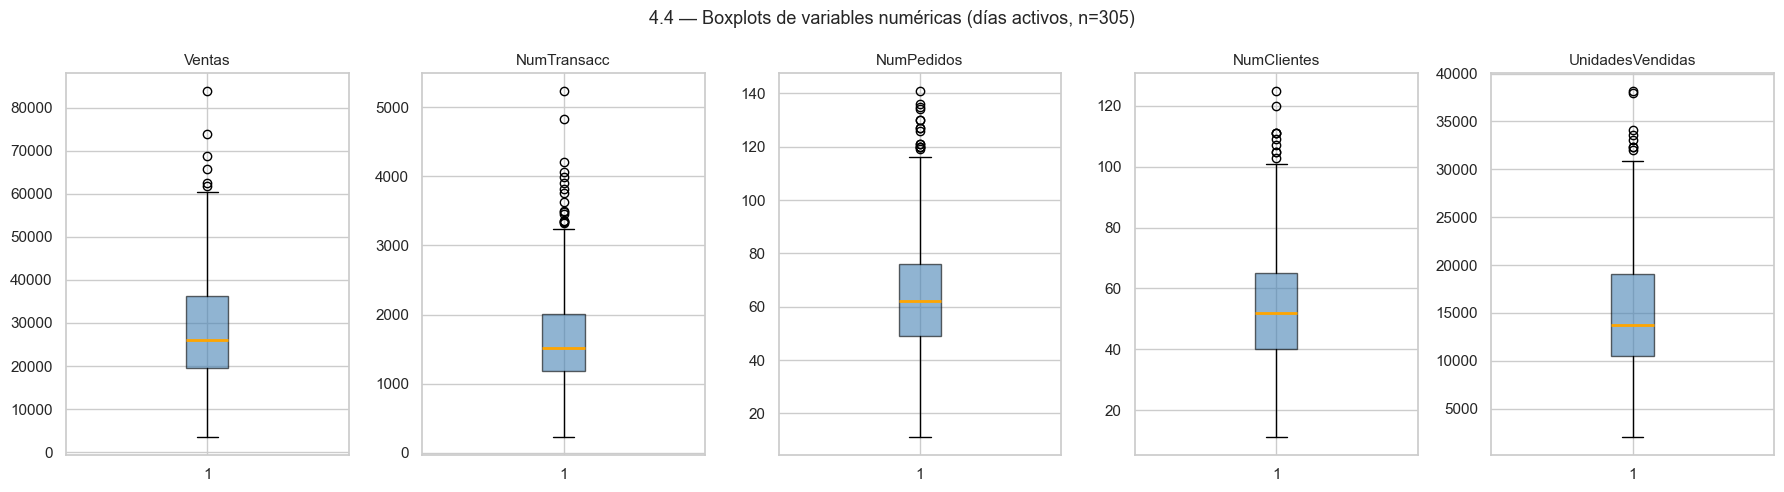

In [13]:
# 4.4.2 — Boxplots de variables numéricas
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(cols_numericas):
    axes[i].boxplot(df_activos[col].values, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='orange', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')
fig.suptitle(f'4.4 — Boxplots de variables numéricas (días activos, n={len(df_activos)})',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.4_boxplots_variables_diarias.png', dpi=150)
plt.show()


In [14]:
# 4.4.3 — Verificar rangos de variables temporales
print("  -- 4.4.3 Verificación de rangos en variables temporales --")
rangos_esperados = {
    'DiaSemana':     (0, 6),
    'EsFinDeSemana': (0, 1),
    'Mes':           (1, 12),
    'Trimestre':     (1, 4),
    'SemanaMes':     (1, 5),
    'DiaAnio':       (1, 366),
    'SemanaAnio':    (1, 53),
}
todo_ok = True
for col, (min_esp, max_esp) in rangos_esperados.items():
    min_real = int(df_daily[col].min())
    max_real = int(df_daily[col].max())
    ok = min_real >= min_esp and max_real <= max_esp
    estado = '✓' if ok else '✗ FUERA DE RANGO'
    if not ok:
        todo_ok = False
    print(f"  {col:<16}: esperado [{min_esp:>3}, {max_esp:>3}]  →  real [{min_real:>3}, {max_real:>3}]  {estado}")
print(f"\n  {'✓ Todas las variables temporales dentro de rango esperado.' if todo_ok else '✗ Revisar columnas marcadas.'}")


  -- 4.4.3 Verificación de rangos en variables temporales --
  DiaSemana       : esperado [  0,   6]  →  real [  0,   6]  ✓
  EsFinDeSemana   : esperado [  0,   1]  →  real [  0,   1]  ✓
  Mes             : esperado [  1,  12]  →  real [  1,  12]  ✓
  Trimestre       : esperado [  1,   4]  →  real [  1,   4]  ✓
  SemanaMes       : esperado [  1,   5]  →  real [  1,   5]  ✓
  DiaAnio         : esperado [  1, 366]  →  real [  1, 365]  ✓
  SemanaAnio      : esperado [  1,  53]  →  real [  1,  52]  ✓

  ✓ Todas las variables temporales dentro de rango esperado.


In [15]:
# 4.4.4 — Análisis de variables categóricas
print("  -- 4.4.4 Análisis de variables categóricas --")

print("\n  ProductoTopDia — top 15 más frecuentes:")
freq_prod  = df_daily['ProductoTopDia'].value_counts()
raros_prod = freq_prod[(freq_prod <= 2) & (freq_prod.index != 'Sin_Actividad')]
print(freq_prod.head(15).to_string())
print(f"\n  Productos únicos (excl. Sin_Actividad): "
      f"{(freq_prod.index != 'Sin_Actividad').sum()}")
print(f"  Productos con ≤2 apariciones (raros): {len(raros_prod)}")
if len(raros_prod) > 0:
    print(f"  → Productos raros: {raros_prod.index.tolist()}")

print("\n  PaisTopDia — distribución completa:")
print(df_daily['PaisTopDia'].value_counts().to_string())
n_uk      = (df_daily['PaisTopDia'] == 'United Kingdom').sum()
n_activos = (df_daily['Ventas'] > 0).sum()
print(f"\n  'United Kingdom' domina {n_uk}/{n_activos} días activos "
      f"({n_uk/n_activos*100:.1f}%) → varianza prácticamente nula → se eliminará en 4.6")


  -- 4.4.4 Análisis de variables categóricas --

  ProductoTopDia — top 15 más frecuentes:
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
21212            10
84879            10
23203             8
47566             7
71459             5
22178             5
22086             5
22834             4
20725             4

  Productos únicos (excl. Sin_Actividad): 109
  Productos con ≤2 apariciones (raros): 89
  → Productos raros: ['84946', '22355', '21985', '85099F', '17003', '21080', '22386', '84991', '22659', '23199', '22740', '84978', '22469', '22151', '16259', '22961', '23310', '75049L', '23209', '16045', '21181', '22952', '22065', '22867', '21844', '17012C', '70006', '84826', '22326', '82581', '20717', '21231', '72741', '22189', '21326', '21918', '22969', '20719', '22908', '21731', '21498', '21878', '22616', '22855', '22741', '20718', '85099C', '22294', '85093', '21749', '23077', '21398', '23207', '

In [16]:
# 4.4.5 — Decisión y conclusión sobre el tratamiento de outliers
print("  -- 4.4.5 Decisión sobre tratamiento de outliers --")
print("""
  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene ~374 filas (~305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
      temporal que el modelo debe aprender.
    → Las ventanas rolling (4.8) y lags (4.7) incorporarán el contexto
      histórico y suavizarán la señal para el modelo.
""")
print(f"  ✓ df_daily sin cambios estructurales: {len(df_daily)} filas, "
      f"{len(df_daily.columns)} columnas.")


  -- 4.4.5 Decisión sobre tratamiento de outliers --

  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene ~374 filas (~305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
  

In [11]:
# [DOC] generamos variables temporales básicas, variables de memoria y ventanas móviles

# [DOC] Variables Temporales Básicas
df_daily_sales['DayOfWeek'] = df_daily_sales['Date'].dt.dayofweek
df_daily_sales['Month'] = df_daily_sales['Date'].dt.month
df_daily_sales['IsWeekend'] = df_daily_sales['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# [DOC] Variables de Memoria (Lags)
# No solo el día anterior (Lag 1), sino el mismo día de la semana pasada (Lag 7)
df_daily_sales['Sales_Lag1'] = df_daily_sales['Sales'].shift(1)
df_daily_sales['Sales_Lag7'] = df_daily_sales['Sales'].shift(7)

# [DOC] Ventanas Móviles (Rolling Windows)
# Promedio de ventas de los últimos 7 días (suaviza picos aislados)
df_daily_sales['Rolling_Mean_7'] = df_daily_sales['Sales'].shift(1).rolling(window=7).mean()

df_daily_sales.dropna(inplace=True)

NameError: name 'df_daily_sales' is not defined

In [ ]:
# [DOC] Aplicamos One-Hot Encoding para el día de la semana y separamos el conjunto de entrenamiento y test antes de escalar

df_daily_sales = pd.get_dummies(df_daily_sales, columns=['DayOfWeek'], prefix='Day')

split_date = pd.to_datetime('2011-11-09')

df_train = df_daily_sales[df_daily_sales['Date'] < split_date].copy()
df_test = df_daily_sales[df_daily_sales['Date'] >= split_date].copy()

print(f"[INFO] Registros Entrenamiento: {len(df_train)}")
print(f"[INFO] Registros Test: {len(df_test)}")

In [ ]:
# [DOC] Escalamos las variables numéricas para que todas tengan el mismo peso en el modelo.

features_to_scale = ['Sales_Lag1', 'Sales_Lag7', 'Rolling_Mean_7', 'TransactionCount']
scaler = StandardScaler()

df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])

In [ ]:
# [DOC] Realizamos el guardado de los datos procesados

output_dir = '../../data/processed'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"[INFO] Carpeta creada con éxito: {output_dir}")

df_train.to_csv(os.path.join(output_dir, 'train_data.csv'), index=False)
df_test.to_csv(os.path.join(output_dir, 'test_data.csv'), index=False)

print(f"[SUCCESS] Archivos guardados correctamente en: {output_dir}")
display(df_train.head())